# Avaliação Quantitativa, Qualitativa e Concordância

##Objetivo

Consolidação das predições das estratégias utilizadas, recalculação de todas as métricas de maneira uniforme, selecão da melhor configuração de cada família de modelos, criação de gráficos de demonstração e comparação, produção de amostra cega para avaliação manual e calculo da concordância entre os cinco avaliadores.

## Arquivos necessários

- `brscams_preprocessado.csv`
- `predicoes_heuristica.csv`
- `predicoes_naivebayes_logreg.csv`
- `predicoes_svm_arvores.csv`

Este notebook recalcula as métricas diretamente a partir das predições.

## 1. Instalação e importações

In [ ]:
!pip install -q statsmodels

import os
import re
import itertools
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    cohen_kappa_score,
)
from statsmodels.stats.inter_rater import fleiss_kappa

RANDOM_STATE = 42
ROTULOS = ['Ham', 'Spam']

## 2. Upload e validação dos arquivos

In [ ]:
print('Selecione os quatro arquivos CSV listados na introdução:')
uploaded = files.upload()

arquivos = set(uploaded.keys())
necessarios = {
    'brscams_preprocessado.csv',
    'predicoes_heuristica.csv',
    'predicoes_naivebayes_logreg.csv',
    'predicoes_svm_arvores.csv',
}
faltantes = necessarios - arquivos
if faltantes:
    raise FileNotFoundError(f'Arquivos não enviados: {sorted(faltantes)}')

df = pd.read_csv('brscams_preprocessado.csv')
pred_h = pd.read_csv('predicoes_heuristica.csv')
pred_nb_lr = pd.read_csv('predicoes_naivebayes_logreg.csv')
pred_svm_arv = pd.read_csv('predicoes_svm_arvores.csv')

print('Dataset:', df.shape)
print('Heurística:', pred_h.shape)
print('NB/LogReg:', pred_nb_lr.shape)
print('SVM/Árvores:', pred_svm_arv.shape)

Selecione os quatro arquivos CSV listados na introdução:


Saving predicoes_svm_arvores.csv to predicoes_svm_arvores.csv
Saving predicoes_naivebayes_logreg.csv to predicoes_naivebayes_logreg.csv
Saving predicoes_heuristica.csv to predicoes_heuristica.csv
Saving brscams_preprocessado.csv to brscams_preprocessado.csv
Dataset: (450, 10)
Heurística: (450, 4)
NB/LogReg: (450, 9)
SVM/Árvores: (450, 13)


In [ ]:
def validar_rotulos(serie, nome):
    valores = set(serie.dropna().astype(str).str.strip())
    invalidos = valores - set(ROTULOS)
    if invalidos:
        raise ValueError(f'{nome} contém rótulos inválidos: {invalidos}')

n = len(df)
for nome, tabela in {
    'heurística': pred_h,
    'NB/LogReg': pred_nb_lr,
    'SVM/árvores': pred_svm_arv,
}.items():
    if len(tabela) != n:
        raise ValueError(f'O arquivo de {nome} tem {len(tabela)} linhas, mas o dataset tem {n}.')

y_real = df['classe_binaria'].astype(str).str.strip().reset_index(drop=True)
validar_rotulos(y_real, 'classe_binaria')

# Confere se os arquivos mantiveram a mesma ordem das 450 instâncias.
if 'classe_binaria' in pred_h.columns:
    if not pred_h['classe_binaria'].astype(str).str.strip().reset_index(drop=True).equals(y_real):
        raise ValueError('A ordem dos rótulos no arquivo heurístico não coincide com o dataset.')

for nome, tabela in [('NB/LogReg', pred_nb_lr), ('SVM/árvores', pred_svm_arv)]:
    if 'Rotulo_Real' not in tabela.columns:
        raise ValueError(f'O arquivo {nome} não possui a coluna Rotulo_Real.')
    if not tabela['Rotulo_Real'].astype(str).str.strip().reset_index(drop=True).equals(y_real):
        raise ValueError(f'A ordem dos rótulos em {nome} não coincide com o dataset.')

print('Validação concluída: número de linhas, rótulos e ordem estão consistentes.')

Validação concluída: número de linhas, rótulos e ordem estão consistentes.


## 3. Consolidação das predições

In [ ]:
predicoes = pd.DataFrame({
    'id_instancia': np.arange(n),
    'Mensagem': df['Mensagem'],
    'Categoria_original': df['Categoria'],
    'Rotulo_Real': y_real,
})

predicoes['Pred_Heuristica'] = pred_h['predicao_heuristica'].astype(str).str.strip()

for tabela in [pred_nb_lr, pred_svm_arv]:
    for coluna in tabela.columns:
        if coluna.startswith('Pred_'):
            if coluna in predicoes.columns:
                raise ValueError(f'Coluna de predição duplicada: {coluna}')
            predicoes[coluna] = tabela[coluna].astype(str).str.strip()

for coluna in [c for c in predicoes.columns if c.startswith('Pred_')]:
    validar_rotulos(predicoes[coluna], coluna)

# Baseline trivial: predizer sempre a classe majoritária.
predicoes['Pred_Baseline_Sempre_Spam'] = 'Spam'

print(f'Total de configurações consolidadas: {len([c for c in predicoes if c.startswith("Pred_")])}')
predicoes.head()

Total de configurações consolidadas: 22


,id_instancia,Mensagem,Categoria_original,Rotulo_Real,Pred_Heuristica,Pred_NaiveBayes_BoW_Padrao,Pred_NaiveBayes_TFIDF_Padrao,Pred_NaiveBayes_BoW_Balanceado,Pred_NaiveBayes_TFIDF_Balanceado,Pred_LogReg_BoW_Padrao,...,Pred_SVM_TFIDF_Balanceado,Pred_ArvoreDecisao_BoW_Padrao,Pred_ArvoreDecisao_BoW_Balanceado,Pred_ArvoreDecisao_TFIDF_Padrao,Pred_ArvoreDecisao_TFIDF_Balanceado,Pred_RandomForest_BoW_Padrao,Pred_RandomForest_BoW_Balanceado,Pred_RandomForest_TFIDF_Padrao,Pred_RandomForest_TFIDF_Balanceado,Pred_Baseline_Sempre_Spam
0,0,"""✨ 3 Sinais Espirituais de que o amor de vocês...",Golpes Baseados Em Relacionamento,Spam,Spam,Spam,Spam,Spam,Spam,Spam,...,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Spam
1,1,"""✅Se você está passando por alguma dificuldade...",Golpes Baseados Em Relacionamento,Spam,Spam,Spam,Spam,Spam,Spam,Spam,...,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Spam
2,2,Sou solteiro e procuro uma namorada para ser m...,Golpes Baseados Em Relacionamento,Spam,Spam,Spam,Spam,Spam,Spam,Spam,...,Spam,Spam,Ham,Ham,Spam,Spam,Spam,Spam,Ham,Spam
3,3,"""Eu sou Amanda. 🌹\nMentora espiritual e criado...",Golpes Baseados Em Relacionamento,Spam,Spam,Ham,Spam,Spam,Spam,Spam,...,Spam,Spam,Ham,Spam,Spam,Spam,Spam,Spam,Spam,Spam
4,4,"""Ótimo diia e feliz domingo pra vocês tudos me...",Golpes Baseados Em Relacionamento,Spam,Ham,Ham,Spam,Spam,Spam,Spam,...,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Spam,Ham,Spam


## 4. Cálculo uniforme das métricas

In [ ]:
def familia_modelo(nome):
    if 'Baseline' in nome:
        return 'Baseline'
    if 'Heuristica' in nome:
        return 'Heurística'
    if 'NaiveBayes' in nome:
        return 'Naive Bayes'
    if 'LogReg' in nome:
        return 'Regressão Logística'
    if 'SVM' in nome:
        return 'SVM'
    if 'ArvoreDecisao' in nome:
        return 'Árvore de Decisão'
    if 'RandomForest' in nome:
        return 'Random Forest'
    return 'Outro'

def metricas_de_predicao(y_true, y_pred, nome_coluna):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=ROTULOS, average='macro', zero_division=0
    )
    rel = classification_report(
        y_true, y_pred, labels=ROTULOS, target_names=ROTULOS,
        output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=ROTULOS)

    nome_modelo = nome_coluna.removeprefix('Pred_')
    return {
        'Modelo': nome_modelo,
        'Família': familia_modelo(nome_modelo),
        'Precisao_Macro': p_macro,
        'Recall_Macro': r_macro,
        'F1_Macro': f1_macro,
        'Acuracia': accuracy_score(y_true, y_pred),
        'Acuracia_Balanceada': balanced_accuracy_score(y_true, y_pred),
        'Precisao_Ham': rel['Ham']['precision'],
        'Recall_Ham': rel['Ham']['recall'],
        'F1_Ham': rel['Ham']['f1-score'],
        'Precisao_Spam': rel['Spam']['precision'],
        'Recall_Spam': rel['Spam']['recall'],
        'F1_Spam': rel['Spam']['f1-score'],
        'Real_Ham_Prev_Ham': int(cm[0, 0]),
        'Real_Ham_Prev_Spam': int(cm[0, 1]),
        'Real_Spam_Prev_Ham': int(cm[1, 0]),
        'Real_Spam_Prev_Spam': int(cm[1, 1]),
    }

linhas = []
for coluna in [c for c in predicoes.columns if c.startswith('Pred_')]:
    linhas.append(metricas_de_predicao(y_real, predicoes[coluna], coluna))

metricas_completas = (
    pd.DataFrame(linhas)
    .sort_values('F1_Macro', ascending=False)
    .reset_index(drop=True)
)

metricas_completas.to_csv('metricas_consolidadas_todas_configuracoes.csv', index=False)
metricas_completas.head(10)

,Modelo,Família,Precisao_Macro,Recall_Macro,F1_Macro,Acuracia,Acuracia_Balanceada,Precisao_Ham,Recall_Ham,F1_Ham,Precisao_Spam,Recall_Spam,F1_Spam,Real_Ham_Prev_Ham,Real_Ham_Prev_Spam,Real_Spam_Prev_Ham,Real_Spam_Prev_Spam
0,LogReg_TFIDF_Balanceado,Regressão Logística,0.698750,0.641333,0.660903,0.837778,0.641333,0.520000,0.346667,0.416000,0.877500,0.936000,0.905806,26,49,24,351
1,ArvoreDecisao_TFIDF_Balanceado,Árvore de Decisão,0.653040,0.654667,0.653843,0.806667,0.654667,0.421053,0.426667,0.423841,0.885027,0.882667,0.883845,32,43,44,331
2,LogReg_BoW_Balanceado,Regressão Logística,0.640107,0.684000,0.653611,0.775556,0.684000,0.379630,0.546667,0.448087,0.900585,0.821333,0.859135,41,34,67,308
3,SVM_BoW_Balanceado,SVM,0.624163,0.672000,0.635858,0.755556,0.672000,0.350427,0.546667,0.427083,0.897898,0.797333,0.844633,41,34,76,299
4,RandomForest_BoW_Balanceado,Random Forest,0.668286,0.613333,0.630199,0.826667,0.613333,0.468085,0.293333,0.360656,0.868486,0.933333,0.899743,22,53,25,350
5,SVM_TFIDF_Padrao,SVM,0.771765,0.602667,0.628750,0.853333,0.602667,0.680000,0.226667,0.340000,0.863529,0.978667,0.917500,17,58,8,367
6,SVM_TFIDF_Balanceado,SVM,0.771765,0.602667,0.628750,0.853333,0.602667,0.680000,0.226667,0.340000,0.863529,0.978667,0.917500,17,58,8,367
7,ArvoreDecisao_BoW_Balanceado,Árvore de Decisão,0.626689,0.625333,0.626002,0.793333,0.625333,0.378378,0.373333,0.375839,0.875000,0.877333,0.876165,28,47,46,329
8,RandomForest_TFIDF_Balanceado,Random Forest,0.623394,0.712000,0.614198,0.688889,0.712000,0.316384,0.746667,0.444444,0.930403,0.677333,0.783951,56,19,121,254
9,LogReg_BoW_Padrao,Regressão Logística,0.680288,0.590667,0.608555,0.833333,0.590667,0.500000,0.226667,0.311927,0.860577,0.954667,0.905183,17,58,17,358


In [ ]:
# Melhor configuração de cada família, mantendo também a baseline.
melhores_por_familia = (
    metricas_completas
    .sort_values('F1_Macro', ascending=False)
    .groupby('Família', as_index=False)
    .first()
    .sort_values('F1_Macro', ascending=False)
    .reset_index(drop=True)
)

melhores_por_familia.to_csv('melhores_modelos_por_familia.csv', index=False)

colunas_exibicao = [
    'Família', 'Modelo', 'Precisao_Macro', 'Recall_Macro',
    'F1_Macro', 'Acuracia', 'Recall_Ham', 'Recall_Spam'
]
melhores_por_familia[colunas_exibicao].round(3)

,Família,Modelo,Precisao_Macro,Recall_Macro,F1_Macro,Acuracia,Recall_Ham,Recall_Spam
0,Regressão Logística,LogReg_TFIDF_Balanceado,0.699,0.641,0.661,0.838,0.347,0.936
1,Árvore de Decisão,ArvoreDecisao_TFIDF_Balanceado,0.653,0.655,0.654,0.807,0.427,0.883
2,SVM,SVM_BoW_Balanceado,0.624,0.672,0.636,0.756,0.547,0.797
3,Random Forest,RandomForest_BoW_Balanceado,0.668,0.613,0.630,0.827,0.293,0.933
4,Naive Bayes,NaiveBayes_TFIDF_Balanceado,0.597,0.633,0.605,0.736,0.480,0.787
5,Baseline,Baseline_Sempre_Spam,0.417,0.500,0.455,0.833,0.000,1.000
6,Heurística,Heuristica,0.535,0.549,0.367,0.373,0.813,0.285


- **F1 macro** é a medida principal, porque atribui a mesma importância a Ham e Spam.
- **Acurácia** é uma medida complementar. Pois um classificador que sempre prevê Spam já alcança aproximadamente 83,3% de acurácia, mas possui recall igual a zero para Ham.
- Além da tabela principal, observe separadamente os recalls de Ham e Spam para identificar o tipo de erro favorecido por cada modelo.

## 5. Gráficos comparativos

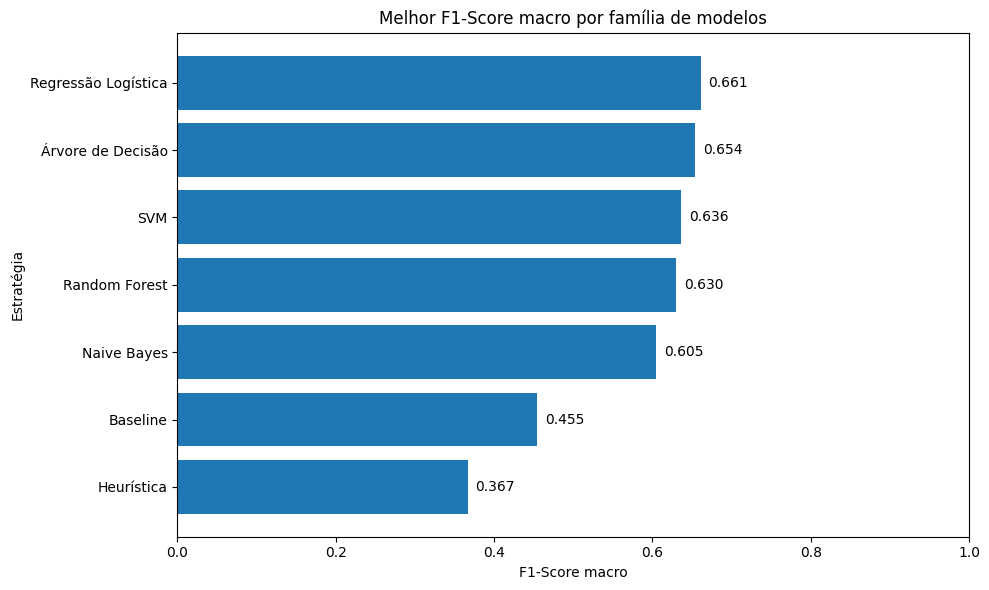

In [ ]:
dados_grafico = melhores_por_familia.sort_values('F1_Macro')

plt.figure(figsize=(10, 6))
plt.barh(dados_grafico['Família'], dados_grafico['F1_Macro'])
plt.xlabel('F1-Score macro')
plt.ylabel('Estratégia')
plt.title('Melhor F1-Score macro por família de modelos')
plt.xlim(0, 1)

for i, valor in enumerate(dados_grafico['F1_Macro']):
    plt.text(valor + 0.01, i, f'{valor:.3f}', va='center')

plt.tight_layout()
plt.savefig('grafico_f1_macro.png', dpi=200, bbox_inches='tight')
plt.show()

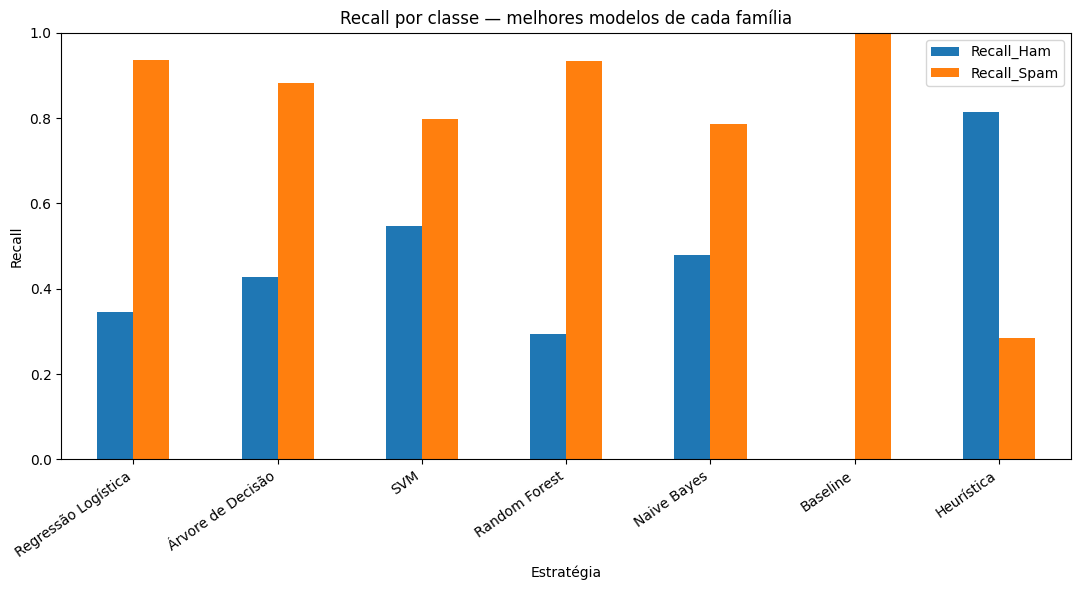

In [ ]:
dados_recall = melhores_por_familia.set_index('Família')[['Recall_Ham', 'Recall_Spam']]

ax = dados_recall.plot(kind='bar', figsize=(11, 6))
ax.set_ylabel('Recall')
ax.set_xlabel('Estratégia')
ax.set_title('Recall por classe — melhores modelos de cada família')
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('grafico_recall_por_classe.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Matrizes de confusão dos três melhores modelos

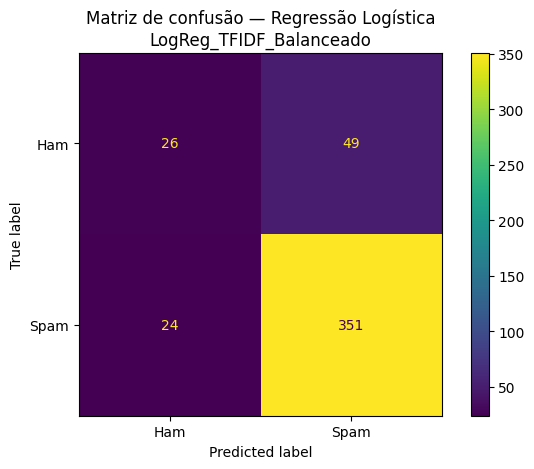

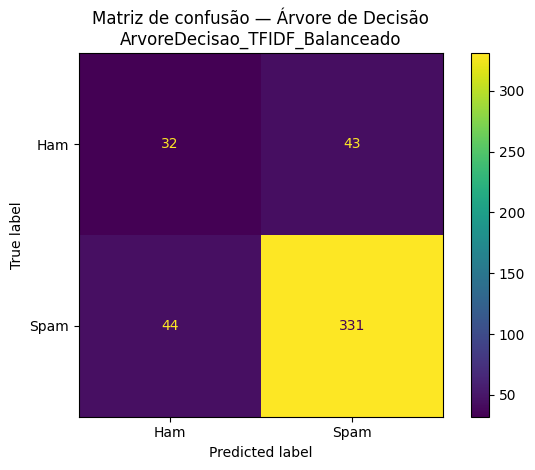

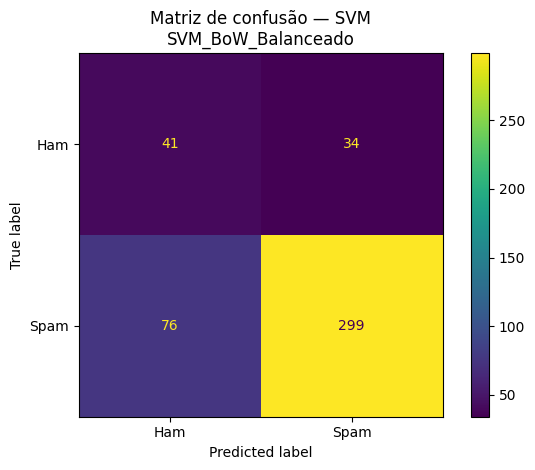

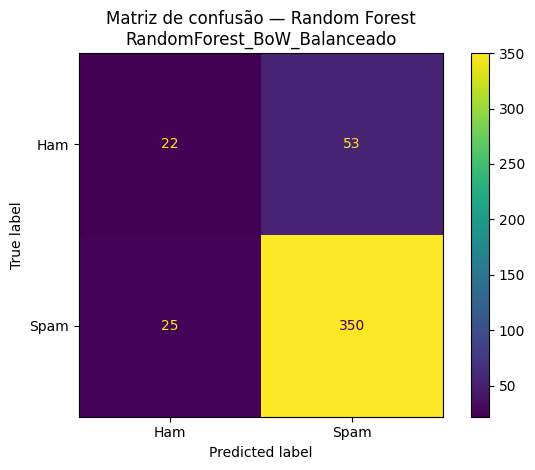

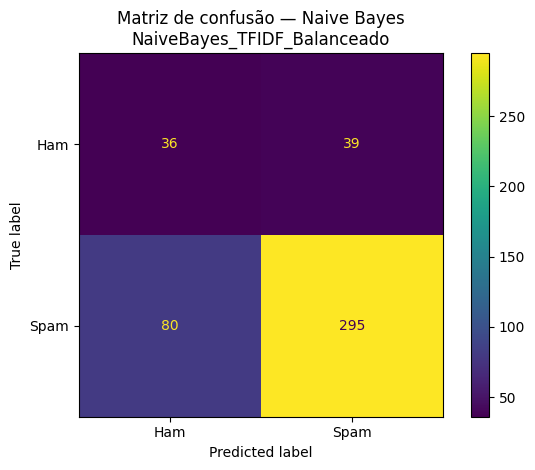

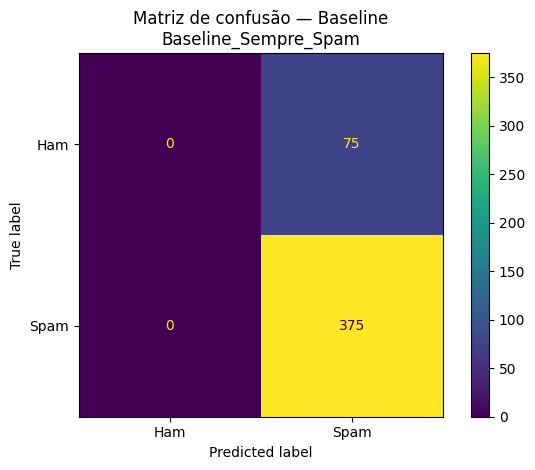

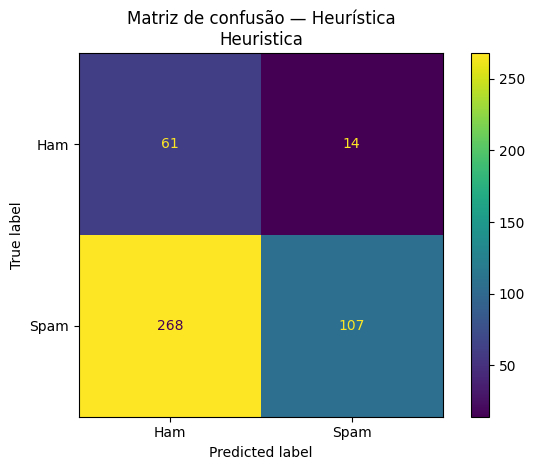

7 matrizes de confusão foram geradas.

Arquivos criados:
- matriz_confusao_Regress_o_Log_stica_LogReg_TFIDF_Balanceado.png
- matriz_confusao_rvore_de_Decis_o_ArvoreDecisao_TFIDF_Balanceado.png
- matriz_confusao_SVM_SVM_BoW_Balanceado.png
- matriz_confusao_Random_Forest_RandomForest_BoW_Balanceado.png
- matriz_confusao_Naive_Bayes_NaiveBayes_TFIDF_Balanceado.png
- matriz_confusao_Baseline_Baseline_Sempre_Spam.png
- matriz_confusao_Heur_stica_Heuristica.png


In [ ]:
# Gera a matriz de confusão para todos os melhores modelos de cada família.
# A baseline também será incluída.

arquivos_matrizes_confusao = []

for _, linha in melhores_por_familia.iterrows():

    familia = linha['Família']
    modelo = linha['Modelo']

    # O nome da coluna de predição segue o padrão Pred_NomeDoModelo.
    coluna_predicao = 'Pred_' + modelo

    # Verifica se a coluna existe antes de calcular a matriz.
    if coluna_predicao not in predicoes.columns:
        print(
            f'Aviso: a coluna "{coluna_predicao}" não foi encontrada. '
            f'A matriz de "{familia}" não será gerada.'
        )
        continue

    # Calcula a matriz de confusão com a mesma ordem de classes.
    cm = confusion_matrix(
        y_real,
        predicoes[coluna_predicao],
        labels=ROTULOS
    )

    # Cria o gráfico.
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=ROTULOS
    )

    disp.plot(values_format='d')

    plt.title(
        f'Matriz de confusão — {familia}\n{modelo}'
    )

    plt.tight_layout()

    # Remove caracteres problemáticos do nome do arquivo.
    nome_seguro = re.sub(
        r'[^A-Za-z0-9_]+',
        '_',
        f'{familia}_{modelo}'
    ).strip('_')

    nome_arquivo = (
        f'matriz_confusao_{nome_seguro}.png'
    )

    plt.savefig(
        nome_arquivo,
        dpi=250,
        bbox_inches='tight'
    )

    arquivos_matrizes_confusao.append(nome_arquivo)

    plt.show()

print(
    f'{len(arquivos_matrizes_confusao)} '
    'matrizes de confusão foram geradas.'
)

print('\nArquivos criados:')

for arquivo in arquivos_matrizes_confusao:
    print('-', arquivo)

## 7. Geração da amostra cega para avaliação qualitativa

A amostra abaixo é contém 20 mensagens Ham e 20 Spam, aleatórias.

Cada integrante recebeu apenas o seu arquivo `avaliacao_Nome.csv`. O arquivo `gabarito_amostra_qualitativa.csv` permaneceu apenas com um integrante do grupo até o término das avaliações, para evitar influência sobre os rótulos manuais.

In [ ]:
n_por_classe = 20

partes = []
for i, classe in enumerate(ROTULOS):
    disponiveis = df[df['classe_binaria'] == classe]
    if len(disponiveis) < n_por_classe:
        raise ValueError(f'Não há {n_por_classe} exemplos da classe {classe}.')
    partes.append(disponiveis.sample(n=n_por_classe, random_state=RANDOM_STATE + i))

amostra = (
    pd.concat(partes)
    .sample(frac=1, random_state=RANDOM_STATE + 10)
    .reset_index()
    .rename(columns={'index': 'indice_dataset'})
)
amostra.insert(0, 'id_amostra', [f'Q{i:02d}' for i in range(1, len(amostra) + 1)])

gabarito = amostra[
    ['id_amostra', 'indice_dataset', 'classe_binaria', 'Categoria']
].rename(columns={'classe_binaria': 'rotulo_dataset'})

gabarito.to_csv('gabarito_amostra_qualitativa.csv', index=False)

nomes_avaliadores = ['Brenda', 'Bruna', 'Joao', 'Julia', 'Larissa']
arquivos_avaliacao = []

for nome in nomes_avaliadores:
    planilha = amostra[['id_amostra', 'Mensagem']].copy()
    planilha['avaliacao_manual'] = ''
    planilha['confianca_1a5'] = ''
    planilha['justificativa_curta'] = ''
    arquivo = f'avaliacao_{nome}.csv'
    planilha.to_csv(arquivo, index=False)
    arquivos_avaliacao.append(arquivo)

with zipfile.ZipFile('templates_avaliacao_qualitativa.zip', 'w') as zf:
    for arquivo in arquivos_avaliacao:
        zf.write(arquivo)
    zf.write('gabarito_amostra_qualitativa.csv')

print('Distribuição real mantida apenas no gabarito:')
print(gabarito['rotulo_dataset'].value_counts())
files.download('templates_avaliacao_qualitativa.zip')

Distribuição real mantida apenas no gabarito:
rotulo_dataset
Spam    20
Ham     20
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Em cada linha:

1. `avaliacao_manual` com exatamente `Ham` ou `Spam`.
2. `confianca_1a5` com um número de 1 a 5.
3. Justificativa curta, especialmente quando a decisão for difícil.

Depois, cada integrante devolve seu próprio CSV preenchido.

## 8. Cálculo da concordância entre os avaliadores

In [ ]:
import io
import os
import re
import pandas as pd
from google.colab import files

ROTULOS = ['Ham', 'Spam']

print(
    'Selecione os cinco arquivos avaliacao_Nome.csv '
    'já preenchidos e o gabarito:'
)

uploaded_avaliacoes = files.upload()


# ==========================================================
# 1. Funções auxiliares
# ==========================================================

def normalizar_nome_arquivo(nome):
    """
    Remove os números acrescentados automaticamente pelo Colab.

    Exemplos:
    avaliacao_Brenda (1).csv -> avaliacao_Brenda.csv
    gabarito_amostra_qualitativa (3).csv
        -> gabarito_amostra_qualitativa.csv
    """
    return re.sub(
        r' \(\d+\)(?=\.csv$)',
        '',
        os.path.basename(nome),
        flags=re.IGNORECASE
    )


def ler_csv_robusto(nome_real, conteudo):
    """
    Tenta abrir um CSV usando diferentes codificações e separadores.

    Isso permite ler arquivos salvos pelo:
    - Google Planilhas;
    - Excel em UTF-8;
    - Excel em ANSI/Windows-1252.
    """

    codificacoes = [
        'utf-8-sig',
        'utf-8',
        'cp1252',
        'latin1'
    ]

    separadores = [
        None,  # detecção automática
        ',',
        ';'
    ]

    erros = []

    for codificacao in codificacoes:
        for separador in separadores:
            try:
                tabela = pd.read_csv(
                    io.BytesIO(conteudo),
                    encoding=codificacao,
                    sep=separador,
                    engine='python'
                )

                # Remove espaços e possíveis marcas BOM dos nomes.
                tabela.columns = (
                    tabela.columns
                    .astype(str)
                    .str.replace('\ufeff', '', regex=False)
                    .str.strip()
                )

                # Uma única coluna geralmente significa que o
                # separador foi interpretado incorretamente.
                if len(tabela.columns) > 1:
                    print(
                        f'Arquivo lido: {nome_real} | '
                        f'codificação={codificacao} | '
                        f'colunas={len(tabela.columns)}'
                    )
                    return tabela

            except Exception as erro:
                erros.append(
                    f'{codificacao} / {separador}: {erro}'
                )

    raise ValueError(
        f'Não foi possível abrir o arquivo "{nome_real}".\n'
        f'Tentativas realizadas:\n' +
        '\n'.join(erros[-6:])
    )


# ==========================================================
# 2. Organização dos arquivos enviados
# ==========================================================

mapa_arquivos = {}

for nome_real, conteudo in uploaded_avaliacoes.items():
    if not nome_real.lower().endswith('.csv'):
        continue

    nome_normalizado = normalizar_nome_arquivo(nome_real)

    if nome_normalizado in mapa_arquivos:
        raise ValueError(
            'Foram enviadas duas versões do mesmo arquivo: '
            f'"{nome_normalizado}".\n'
            'Envie somente uma versão de cada avaliação.'
        )

    mapa_arquivos[nome_normalizado] = {
        'nome_real': nome_real,
        'conteudo': conteudo
    }


nome_gabarito = 'gabarito_amostra_qualitativa.csv'

if nome_gabarito not in mapa_arquivos:
    raise FileNotFoundError(
        'O arquivo gabarito_amostra_qualitativa.csv '
        'não foi enviado.'
    )


arquivos_raters = sorted([
    nome
    for nome in mapa_arquivos
    if nome.lower().startswith('avaliacao_')
])

if len(arquivos_raters) != 5:
    raise ValueError(
        'Devem ser enviados exatamente cinco arquivos de '
        f'avaliadores. Foram encontrados {len(arquivos_raters)}: '
        f'{arquivos_raters}'
    )

print('\nArquivos reconhecidos:')

for nome in arquivos_raters:
    print(
        f'- {nome} -> '
        f'{mapa_arquivos[nome]["nome_real"]}'
    )

print(
    f'- {nome_gabarito} -> '
    f'{mapa_arquivos[nome_gabarito]["nome_real"]}'
)


# ==========================================================
# 3. Leitura do gabarito
# ==========================================================

dados_gabarito = mapa_arquivos[nome_gabarito]

gab = ler_csv_robusto(
    dados_gabarito['nome_real'],
    dados_gabarito['conteudo']
)

colunas_gabarito = {
    'id_amostra',
    'indice_dataset',
    'rotulo_dataset'
}

faltantes_gabarito = colunas_gabarito - set(gab.columns)

if faltantes_gabarito:
    raise ValueError(
        'O gabarito não possui as seguintes colunas: '
        f'{sorted(faltantes_gabarito)}'
    )

gab['id_amostra'] = (
    gab['id_amostra']
    .astype(str)
    .str.strip()
)

gab['rotulo_dataset'] = (
    gab['rotulo_dataset']
    .astype(str)
    .str.strip()
    .str.capitalize()
)

if gab['id_amostra'].duplicated().any():
    ids_duplicados = (
        gab.loc[
            gab['id_amostra'].duplicated(keep=False),
            'id_amostra'
        ]
        .tolist()
    )

    raise ValueError(
        f'O gabarito contém IDs duplicados: {ids_duplicados}'
    )

avaliacoes = gab[
    ['id_amostra', 'indice_dataset', 'rotulo_dataset']
].copy()


# ==========================================================
# 4. Leitura das avaliações
# ==========================================================

for nome_normalizado in arquivos_raters:

    dados_arquivo = mapa_arquivos[nome_normalizado]

    av = ler_csv_robusto(
        dados_arquivo['nome_real'],
        dados_arquivo['conteudo']
    )

    obrigatorias = {
        'id_amostra',
        'avaliacao_manual'
    }

    faltantes = obrigatorias - set(av.columns)

    if faltantes:
        raise ValueError(
            f'O arquivo {nome_normalizado} não possui '
            f'as colunas: {sorted(faltantes)}'
        )

    av['id_amostra'] = (
        av['id_amostra']
        .astype(str)
        .str.strip()
    )

    if av['id_amostra'].duplicated().any():
        ids_duplicados = (
            av.loc[
                av['id_amostra'].duplicated(keep=False),
                'id_amostra'
            ]
            .tolist()
        )

        raise ValueError(
            f'{nome_normalizado} contém IDs duplicados: '
            f'{ids_duplicados}'
        )

    # Guarda o conteúdo original para mostrar erros com clareza.
    respostas_originais = av['avaliacao_manual'].copy()

    # Normalização robusta:
    # HAM, ham, Ham, " Ham " -> Ham
    # SPAM, spam, Spam, " Spam " -> Spam
    respostas_normalizadas = (
        av['avaliacao_manual']
        .astype('string')
        .str.strip()
        .str.casefold()
        .map({
            'ham': 'Ham',
            'spam': 'Spam'
        })
    )

    invalidas = respostas_normalizadas.isna()

    if invalidas.any():
        problemas = av.loc[
            invalidas,
            ['id_amostra']
        ].copy()

        problemas['valor_encontrado'] = (
            respostas_originais.loc[invalidas]
            .astype('string')
        )

        raise ValueError(
            f'\nO arquivo {nome_normalizado} possui respostas '
            f'inválidas ou vazias:\n\n'
            f'{problemas.to_string(index=False)}\n\n'
            'Use somente Ham ou Spam.'
        )

    av['avaliacao_manual'] = respostas_normalizadas

    # Obtém somente o nome da pessoa.
    # avaliacao_Brenda.csv -> Brenda
    nome_avaliador = (
        os.path.splitext(nome_normalizado)[0]
        .replace('avaliacao_', '')
    )

    avaliacoes = avaliacoes.merge(
        av[['id_amostra', 'avaliacao_manual']]
        .rename(
            columns={
                'avaliacao_manual': nome_avaliador
            }
        ),
        on='id_amostra',
        how='left',
        validate='one_to_one'
    )


# ==========================================================
# 5. Validações finais
# ==========================================================

colunas_avaliadores = [
    coluna
    for coluna in avaliacoes.columns
    if coluna not in [
        'id_amostra',
        'indice_dataset',
        'rotulo_dataset'
    ]
]

if avaliacoes[colunas_avaliadores].isna().any().any():

    linhas_incompletas = avaliacoes.loc[
        avaliacoes[colunas_avaliadores]
        .isna()
        .any(axis=1),
        ['id_amostra'] + colunas_avaliadores
    ]

    raise ValueError(
        'Há avaliações ausentes após a junção dos '
        'arquivos:\n\n'
        f'{linhas_incompletas.to_string(index=False)}'
    )

quantidade_gabarito = len(gab)

for avaliador in colunas_avaliadores:
    quantidade_respostas = avaliacoes[avaliador].notna().sum()

    if quantidade_respostas != quantidade_gabarito:
        raise ValueError(
            f'O avaliador {avaliador} possui '
            f'{quantidade_respostas} respostas, mas o '
            f'gabarito possui {quantidade_gabarito} mensagens.'
        )


# ==========================================================
# 6. Resultado
# ==========================================================

print('\nArquivos processados com sucesso.')

print(
    'Avaliadores consolidados:',
    colunas_avaliadores
)

print(
    'Quantidade de mensagens:',
    len(avaliacoes)
)

display(avaliacoes.head())

Selecione os cinco arquivos avaliacao_Nome.csv já preenchidos e o gabarito:


Saving avaliacao_Joao.csv to avaliacao_Joao (1).csv
Saving avaliacao_Bruna.csv to avaliacao_Bruna (1).csv
Saving avaliacao_Brenda.csv to avaliacao_Brenda (1).csv
Saving avaliacao_Julia.csv to avaliacao_Julia (1).csv
Saving avaliacao_Larissa.csv to avaliacao_Larissa (1).csv
Saving gabarito_amostra_qualitativa.csv to gabarito_amostra_qualitativa (1).csv

Arquivos reconhecidos:
- avaliacao_Brenda.csv -> avaliacao_Brenda (1).csv
- avaliacao_Bruna.csv -> avaliacao_Bruna (1).csv
- avaliacao_Joao.csv -> avaliacao_Joao (1).csv
- avaliacao_Julia.csv -> avaliacao_Julia (1).csv
- avaliacao_Larissa.csv -> avaliacao_Larissa (1).csv
- gabarito_amostra_qualitativa.csv -> gabarito_amostra_qualitativa (1).csv
Arquivo lido: gabarito_amostra_qualitativa (1).csv | codificação=utf-8-sig | colunas=4
Arquivo lido: avaliacao_Brenda (1).csv | codificação=utf-8-sig | colunas=5
Arquivo lido: avaliacao_Bruna (1).csv | codificação=utf-8-sig | colunas=5
Arquivo lido: avaliacao_Joao (1).csv | codificação=utf-8-sig |

,id_amostra,indice_dataset,rotulo_dataset,Brenda,Bruna,Joao,Julia,Larissa
0,Q01,366,Spam,Ham,Ham,Ham,Ham,Ham
1,Q02,444,Ham,Ham,Spam,Ham,Spam,Ham
2,Q03,78,Ham,Ham,Ham,Ham,Ham,Ham
3,Q04,346,Spam,Ham,Spam,Spam,Spam,Spam
4,Q05,155,Spam,Spam,Spam,Ham,Ham,Spam


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# Matriz exigida pelo Fleiss' Kappa:
# cada linha é uma mensagem; cada coluna contém a quantidade de votos em Ham/Spam.
contagens = np.column_stack([
    (avaliacoes[colunas_avaliadores] == 'Ham').sum(axis=1),
    (avaliacoes[colunas_avaliadores] == 'Spam').sum(axis=1),
])

kappa_fleiss = fleiss_kappa(contagens, method='fleiss')

# Concordância par a par.
matriz_kappa = pd.DataFrame(
    np.eye(len(colunas_avaliadores)),
    index=colunas_avaliadores,
    columns=colunas_avaliadores,
)

acordos_pares = []
for a, b in itertools.combinations(colunas_avaliadores, 2):
    k = cohen_kappa_score(avaliacoes[a], avaliacoes[b], labels=ROTULOS)
    matriz_kappa.loc[a, b] = k
    matriz_kappa.loc[b, a] = k
    acordos_pares.append((avaliacoes[a] == avaliacoes[b]).mean())

concordancia_media_pares = float(np.mean(acordos_pares))
taxa_unanimidade = float(
    avaliacoes[colunas_avaliadores].nunique(axis=1).eq(1).mean()
)

print(f"Fleiss' Kappa: {kappa_fleiss:.4f}")
print(f'Concordância média entre pares: {concordancia_media_pares:.2%}')
print(f'Taxa de unanimidade: {taxa_unanimidade:.2%}')
print('\nMatriz de Cohen Kappa entre pares:')
display(matriz_kappa.round(3))

Fleiss' Kappa: 0.4687
Concordância média entre pares: 74.50%
Taxa de unanimidade: 45.00%

Matriz de Cohen Kappa entre pares:


,Brenda,Bruna,Joao,Julia,Larissa
Brenda,1.000,0.579,0.333,0.333,0.529
Bruna,0.579,1.000,0.406,0.592,0.588
Joao,0.333,0.406,1.000,0.510,0.515
Julia,0.333,0.592,0.510,1.000,0.362
Larissa,0.529,0.588,0.515,0.362,1.000


In [ ]:
# Voto majoritário. Com cinco avaliadores não ocorre empate.
avaliacoes['votos_Ham'] = contagens[:, 0]
avaliacoes['votos_Spam'] = contagens[:, 1]
avaliacoes['consenso'] = np.where(
    avaliacoes['votos_Spam'] > avaliacoes['votos_Ham'],
    'Spam',
    'Ham'
)
avaliacoes['grau_desacordo'] = (
    1 - avaliacoes[['votos_Ham', 'votos_Spam']].max(axis=1) / len(colunas_avaliadores)
)

# Desempenho manual de cada avaliador e do consenso em relação ao rótulo do dataset.
linhas_manuais = []
for nome in colunas_avaliadores + ['consenso']:
    p, r, f1, _ = precision_recall_fscore_support(
        avaliacoes['rotulo_dataset'],
        avaliacoes[nome],
        labels=ROTULOS,
        average='macro',
        zero_division=0,
    )
    linhas_manuais.append({
        'Avaliador': nome,
        'Precisao_Macro': p,
        'Recall_Macro': r,
        'F1_Macro': f1,
        'Acuracia': accuracy_score(avaliacoes['rotulo_dataset'], avaliacoes[nome]),
    })

metricas_avaliadores = pd.DataFrame(linhas_manuais)
metricas_avaliadores.to_csv('metricas_avaliacao_manual.csv', index=False)
metricas_avaliadores.round(3)

,Avaliador,Precisao_Macro,Recall_Macro,F1_Macro,Acuracia
0,Brenda,0.833,0.750,0.733,0.750
1,Bruna,0.803,0.800,0.799,0.800
2,Joao,0.803,0.800,0.799,0.800
3,Julia,0.708,0.700,0.697,0.700
4,Larissa,0.885,0.850,0.847,0.850
5,consenso,0.900,0.875,0.873,0.875


## 9. Análise qualitativa dos casos difíceis e dos erros dos modelos

In [ ]:
# Recupera mensagem e predições da amostra pelo índice original.
detalhes = avaliacoes.merge(
    predicoes,
    left_on='indice_dataset',
    right_on='id_instancia',
    how='left',
    validate='one_to_one',
)

# Escolhe automaticamente o melhor modelo global, ignorando a baseline.
melhor_global = metricas_completas[
    metricas_completas['Família'] != 'Baseline'
].iloc[0]
coluna_melhor = 'Pred_' + melhor_global['Modelo']

detalhes['melhor_modelo'] = melhor_global['Modelo']
detalhes['predicao_melhor_modelo'] = detalhes[coluna_melhor]
detalhes['erro_melhor_modelo'] = (
    detalhes['predicao_melhor_modelo'] != detalhes['Rotulo_Real']
)
detalhes['erro_heuristica'] = (
    detalhes['Pred_Heuristica'] != detalhes['Rotulo_Real']
)
detalhes['consenso_diverge_dataset'] = (
    detalhes['consenso'] != detalhes['Rotulo_Real']
)

colunas_saida = [
    'id_amostra', 'indice_dataset', 'Mensagem', 'Categoria_original',
    'Rotulo_Real', 'votos_Ham', 'votos_Spam', 'consenso', 'grau_desacordo',
    'melhor_modelo', 'predicao_melhor_modelo', 'erro_melhor_modelo',
    'Pred_Heuristica', 'erro_heuristica', 'consenso_diverge_dataset'
]
detalhes[colunas_saida].to_csv(
    'analise_qualitativa_detalhada.csv', index=False
)

print('Casos com maior desacordo humano:')
display(
    detalhes[colunas_saida]
    .sort_values(['grau_desacordo', 'id_amostra'], ascending=[False, True])
    .head(10)
)

print('\nErros do melhor modelo em que o consenso humano coincide com o dataset:')
display(
    detalhes[
        detalhes['erro_melhor_modelo']
        & ~detalhes['consenso_diverge_dataset']
    ][colunas_saida].head(10)
)

print('\nCasos em que o consenso humano diverge do rótulo do dataset:')
display(
    detalhes[
        detalhes['consenso_diverge_dataset']
    ][colunas_saida].head(10)
)

Casos com maior desacordo humano:


,id_amostra,indice_dataset,Mensagem,Categoria_original,Rotulo_Real,votos_Ham,votos_Spam,consenso,grau_desacordo,melhor_modelo,predicao_melhor_modelo,erro_melhor_modelo,Pred_Heuristica,erro_heuristica,consenso_diverge_dataset
1,Q02,444,“Nós temos hoje no Brasil 33 milhões de pessoa...,Seguro,Ham,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Ham,False,Spam,True,False
4,Q05,155,"De: Wendy A Robinson <[email protected]>Olá, m...",Fraudes em Lojas Virtuais Falsas,Spam,2,3,Spam,0.4,LogReg_TFIDF_Balanceado,Spam,False,Ham,True,False
8,Q09,392,“Esses são os seus eleitores”,Golpes de Desinformação Digital,Spam,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Ham,True,Ham,True,True
12,Q13,424,“Nos últimos 12 meses o Brasil pagou R$ 500 bi...,Seguro,Ham,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Ham,False,Spam,True,False
26,Q27,389,Faltando 4 dias corridos pro 1 turno em 2018 o...,Golpes de Desinformação Digital,Spam,2,3,Spam,0.4,LogReg_TFIDF_Balanceado,Spam,False,Ham,True,False
32,Q33,436,“[O MDB] É o partido que tem o maior número de...,Seguro,Ham,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
39,Q40,157,Registro Whois para MdBusinessSales.comRegistr...,Fraudes em Lojas Virtuais Falsas,Spam,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Spam,False,Ham,True,True
3,Q04,346,Mais uma palhaçada da Cristina Kirchner Comuni...,Golpes de Desinformação Digital,Spam,1,4,Spam,0.2,LogReg_TFIDF_Balanceado,Spam,False,Ham,True,False
5,Q06,138,"Eles são tão bonitos, resistentes, assim como ...",Seguro,Ham,4,1,Ham,0.2,LogReg_TFIDF_Balanceado,Ham,False,Ham,False,False
6,Q07,431,"“O presidente [Alberto Fernández, da Argentina...",Seguro,Ham,4,1,Ham,0.2,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False



Erros do melhor modelo em que o consenso humano coincide com o dataset:


,id_amostra,indice_dataset,Mensagem,Categoria_original,Rotulo_Real,votos_Ham,votos_Spam,consenso,grau_desacordo,melhor_modelo,predicao_melhor_modelo,erro_melhor_modelo,Pred_Heuristica,erro_heuristica,consenso_diverge_dataset
2,Q03,78,"bom dia meus amigos queridos, vamos almoçar um...",Seguro,Ham,5,0,Ham,0.0,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
6,Q07,431,"“O presidente [Alberto Fernández, da Argentina...",Seguro,Ham,4,1,Ham,0.2,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
9,Q10,223,Então eu pago primeiro... Depois quando o esto...,Seguro,Ham,4,1,Ham,0.2,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
11,Q12,140,Ótima xícara. Durará para sempre. Mantém as co...,Seguro,Ham,4,1,Ham,0.2,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
13,Q14,216,Tenho procurado as palavras certas para agrade...,Seguro,Ham,4,1,Ham,0.2,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
14,Q15,210,Ok lar... Brincando com você oni...,Seguro,Ham,5,0,Ham,0.0,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
21,Q22,221,É sério assim que você soletra o nome dele?,Seguro,Ham,5,0,Ham,0.0,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
31,Q32,222,Vou tentar por 2 meses ha ha só brincando,Seguro,Ham,5,0,Ham,0.0,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
32,Q33,436,“[O MDB] É o partido que tem o maior número de...,Seguro,Ham,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False
37,Q38,163,Haha você é sempre tão convincente.,Seguro,Ham,5,0,Ham,0.0,LogReg_TFIDF_Balanceado,Spam,True,Ham,False,False



Casos em que o consenso humano diverge do rótulo do dataset:


,id_amostra,indice_dataset,Mensagem,Categoria_original,Rotulo_Real,votos_Ham,votos_Spam,consenso,grau_desacordo,melhor_modelo,predicao_melhor_modelo,erro_melhor_modelo,Pred_Heuristica,erro_heuristica,consenso_diverge_dataset
0,Q01,366,"A mulher que é dona de casa, solteira e comand...",Golpes de Desinformação Digital,Spam,5,0,Ham,0.0,LogReg_TFIDF_Balanceado,Spam,False,Spam,False,True
8,Q09,392,“Esses são os seus eleitores”,Golpes de Desinformação Digital,Spam,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Ham,True,Ham,True,True
29,Q30,58,Estes parecem lindos e tão legais. O único pro...,Fraudes em Lojas Virtuais Falsas,Spam,5,0,Ham,0.0,LogReg_TFIDF_Balanceado,Spam,False,Ham,True,True
30,Q31,378,"Fui o governador mais popular do Brasil, olhe ...",Golpes de Desinformação Digital,Spam,4,1,Ham,0.2,LogReg_TFIDF_Balanceado,Ham,True,Ham,True,True
39,Q40,157,Registro Whois para MdBusinessSales.comRegistr...,Fraudes em Lojas Virtuais Falsas,Spam,3,2,Ham,0.4,LogReg_TFIDF_Balanceado,Spam,False,Ham,True,True


## 10. Exportação dos resultados finais

Os arquivos abaixo devem ser usados no relatório, nos slides e no repositório do grupo.

In [ ]:
import os
import glob
import zipfile

# Lista de arquivos que serão incluídos no ZIP.
arquivos_finais = []


# 1. Tabelas quantitativas principais

arquivos_obrigatorios = [
    'metricas_consolidadas_todas_configuracoes.csv',
    'melhores_modelos_por_familia.csv',
    'tabela_melhores_modelos_por_familia.png',
    'grafico_f1_macro.png',
    'grafico_recall_por_classe.png',
]

for arquivo in arquivos_obrigatorios:
    if os.path.exists(arquivo):
        arquivos_finais.append(arquivo)
    else:
        print(
            f'Aviso: o arquivo obrigatório "{arquivo}" '
            'não foi encontrado.'
        )


arquivos_finais.extend(matrizes_encontradas)

# 3. Resultados da avaliação qualitativa

arquivos_qualitativos = [
    'metricas_avaliacao_manual.csv',
    'analise_qualitativa_detalhada.csv',
]

for arquivo in arquivos_qualitativos:
    if os.path.exists(arquivo):
        arquivos_finais.append(arquivo)

# 5. Remove duplicatas e ordena

arquivos_finais = sorted(set(arquivos_finais))


# 6. Cria o arquivo ZIP

nome_zip = 'resultados_pessoa_5.zip'

with zipfile.ZipFile(
    nome_zip,
    'w',
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for arquivo in arquivos_finais:
        if os.path.exists(arquivo):
            zf.write(
                arquivo,
                arcname=os.path.basename(arquivo)
            )


# 8. Mostra o conteúdo incluído

print(
    f'\nArquivo ZIP criado com sucesso: {nome_zip}'
)

print(
    f'Total de arquivos incluídos: '
    f'{len(arquivos_finais)}'
)

print('\nArquivos incluídos no ZIP:')

for arquivo in arquivos_finais:
    if os.path.exists(arquivo):
        print('-', arquivo)

# Faz o download
files.download(nome_zip)

Aviso: o arquivo obrigatório "tabela_melhores_modelos_por_familia.png" não foi encontrado.

Arquivo ZIP criado com sucesso: resultados_pessoa_5.zip
Total de arquivos incluídos: 13

Arquivos incluídos no ZIP:
- analise_qualitativa_detalhada.csv
- grafico_f1_macro.png
- grafico_recall_por_classe.png
- matriz_confusao_Baseline_Baseline_Sempre_Spam.png
- matriz_confusao_Heur_stica_Heuristica.png
- matriz_confusao_Naive_Bayes_NaiveBayes_TFIDF_Balanceado.png
- matriz_confusao_Random_Forest_RandomForest_BoW_Balanceado.png
- matriz_confusao_Regress_o_Log_stica_LogReg_TFIDF_Balanceado.png
- matriz_confusao_SVM_SVM_BoW_Balanceado.png
- matriz_confusao_rvore_de_Decis_o_ArvoreDecisao_TFIDF_Balanceado.png
- melhores_modelos_por_familia.csv
- metricas_avaliacao_manual.csv
- metricas_consolidadas_todas_configuracoes.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>